In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists() and (PROJECT_ROOT.parent / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.stats import wasserstein_distance

from comet_ml import Experiment

from scripts.utils import AgingFactorGenerator, aggregate_cell_stats, get_cellid_counts_per_event, filter_by_xyz
from scripts.plot_graphics import PlotGenerator, plot_true_vs_predicted, plot_error_histogram

In [4]:
import os

os.environ["COMET_API_KEY"] = "ZvzFX4CUjN8omegkDEAzWRoTf"
os.environ["COMET_WORKSPACE"] = "redroseonmyhand"
os.environ["COMET_PROJECT_NAME"] = "calorimeter-wgan"

In [14]:
config_path = PROJECT_ROOT / "configs" / "config.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)
df = pd.read_csv(PROJECT_ROOT / config["data_path"])
aging_cfg = config.get("aging", {})
results_dir = PROJECT_ROOT / config["results_dir"]
results_dir.mkdir(exist_ok=True)

In [15]:
generator = AgingFactorGenerator(
    aging_function=aging_cfg.get("function", "xyz"),
    af_min=aging_cfg.get("af_min", 0.8),
    af_max=aging_cfg.get("af_max", 1.0),
    sigma=aging_cfg.get("sigma", 0.0),
    noise_seed=aging_cfg.get("noise_seed"),
    event_col=aging_cfg.get("event_col", "event"),
    x_col=aging_cfg.get("x_col", "x"),
    y_col=aging_cfg.get("y_col", "y"),
    z_col=aging_cfg.get("z_col", "z"),
    energy_col=aging_cfg.get("energy_col", "E"),
)
aged = generator.generate(df)
dataset = aged[[generator.event_col, "cell_key", generator.x_col, generator.y_col, generator.z_col, "E_new", "E_old", "aging_factor"]]
dataset

,event,cell_key,x,y,z,E_new,E_old,aging_factor
0,0,"(7.5, -25.5, -136.4915)",7.5,-25.5,-136.4915,682.457989,571.407704,0.837279
1,0,"(-4.5, -16.5, -131.4905)",-4.5,-16.5,-131.4905,219.605838,179.293504,0.816433
2,0,"(-4.5, -13.5, -131.4905)",-4.5,-13.5,-131.4905,1274.081248,1033.467502,0.811147
3,0,"(-1.5, -16.5, -131.4905)",-1.5,-16.5,-131.4905,447.282884,364.717012,0.815406
4,0,"(-1.5, -16.5, -126.4895)",-1.5,-16.5,-126.4895,627.502513,511.926561,0.815816
...,...,...,...,...,...,...,...,...
1185644,99999,"(4.5, -1.5, -96.48350000000002)",4.5,-1.5,-96.4835,1085.950017,870.094599,0.801229
1185645,99999,"(7.5, -1.5, -96.48350000000002)",7.5,-1.5,-96.4835,336.263208,270.452287,0.804287
1185646,99999,"(1.5, 4.5, -91.48250000000002)",1.5,4.5,-91.4825,754.862836,605.127649,0.801639
1185647,99999,"(4.5, 7.5, -91.48250000000002)",4.5,7.5,-91.4825,636.009632,512.666880,0.806068


In [ ]:
x_range = (-34.5, 34.5)
y_range = (-34.5, 34.5)
z_range = (-116.4875, -46.4735)

In [17]:
k = 90000
seed_new = 42
seed_old = 123
event_col = generator.event_col

In [18]:
unique_events = dataset[event_col].drop_duplicates()

events_new = unique_events.sample(n=k, random_state=seed_new)
events_old = unique_events.sample(n=k, random_state=seed_old)

data_E_new = dataset[dataset[event_col].isin(events_new)].copy().reset_index(drop=True)
data_E_old = dataset[dataset[event_col].isin(events_old)].copy().reset_index(drop=True)

data_E_new = filter_by_xyz(data_E_new, x_range, y_range, z_range)
data_E_old = filter_by_xyz(data_E_old, x_range, y_range, z_range)

In [19]:
base_cols = [event_col, "cell_key", "x", "y", "z"]

data_E_new = data_E_new[base_cols + ["E_new"]] \
    .rename(columns={"E_new": "E"})

data_E_old = data_E_old[base_cols + ["E_old"]] \
    .rename(columns={"E_old": "E"})

Mean Model

In [20]:
mean_new = (
    data_E_new
    .groupby("cell_key")["E"]
    .mean()
    .rename("mu_new")
)

mean_old = (
    data_E_old
    .groupby("cell_key")["E"]
    .mean()
    .rename("mu_old")
)

In [21]:
mean_df = pd.concat([mean_new, mean_old], axis=1)

mean_df = mean_df.dropna()

counts_new = data_E_new.groupby("cell_key")["E"].size()
counts_old = data_E_old.groupby("cell_key")["E"].size()

mean_df = mean_df.join(counts_new.rename("n_new"))
mean_df = mean_df.join(counts_old.rename("n_old"))


mean_df["a_hat_mean"] = mean_df["mu_old"] / mean_df["mu_new"]

In [22]:
a_true = (
    dataset
    .groupby("cell_key")["aging_factor"]
    .mean()
    .rename("a_true")
)

mean_df = mean_df.join(a_true, how="inner")

In [ ]:
mean_df

,mu_new,mu_old,n_new,n_old,a_hat_mean,a_true
cell_key,,,,,,
"(-28.5, -28.5, -96.48350000000002)",1607.066565,1409.459657,68,68,0.877039,0.880317
"(-28.5, -28.5, -91.48250000000002)",2130.520446,1942.818151,51,49,0.911898,0.880727
"(-28.5, -28.5, -86.48150000000001)",1507.643303,1562.852651,52,52,1.036620,0.881138
"(-28.5, -28.5, -81.48050000000002)",835.799032,751.600105,46,43,0.899259,0.881548
"(-28.5, -25.5, -96.48350000000002)",1935.977287,1734.981937,83,82,0.896179,0.873727
...,...,...,...,...,...,...
"(28.5, 25.5, -81.48050000000002)",1790.225787,1540.343934,38,39,0.860419,0.874958
"(28.5, 28.5, -96.48350000000002)",1498.654954,981.124147,57,55,0.654670,0.880317
"(28.5, 28.5, -91.48250000000002)",2075.648873,1931.716875,60,55,0.930657,0.880727


In [23]:
rmse_mean = np.sqrt(np.mean((mean_df["a_true"] - mean_df["a_hat_mean"])**2))
rmse_mean

np.float64(0.03347841624683333)

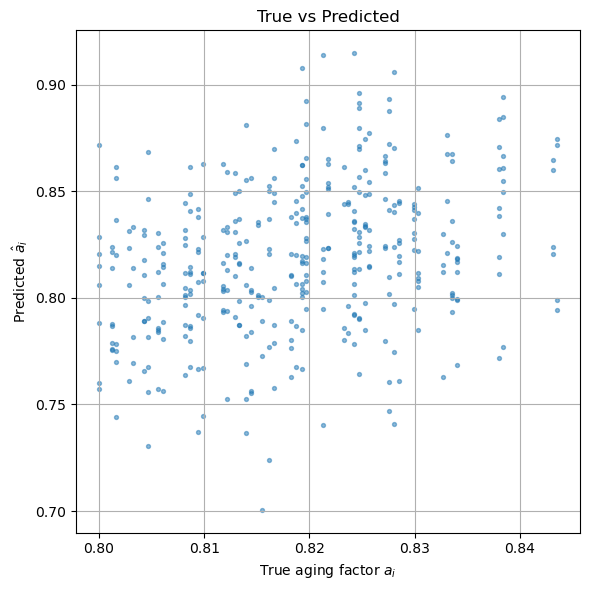

In [24]:
plot_true_vs_predicted(mean_df, "a_true", "a_hat_mean")

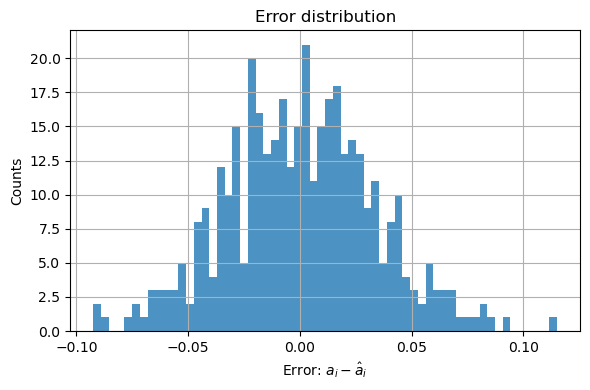

In [26]:
plot_error_histogram(mean_df, "a_true", "a_hat_mean")

Median Model

In [27]:
median_new = (
    data_E_new
    .groupby("cell_key")["E"]
    .median()
    .rename("m_new")
)

median_old = (
    data_E_old
    .groupby("cell_key")["E"]
    .median()
    .rename("m_old")
)

median_df = pd.concat([median_new, median_old], axis=1)

median_df = median_df.dropna()

median_df = median_df.join(counts_new.rename("n_new"))
median_df = median_df.join(counts_old.rename("n_old"))

median_df["a_hat_median"] = median_df["m_old"] / median_df["m_new"]


a_true = (
    dataset
    .groupby("cell_key")["aging_factor"]
    .mean()
    .rename("a_true")
)

median_df = median_df.join(a_true, how="inner")

In [28]:
rmse_median = np.sqrt(np.mean((median_df["a_true"] - median_df["a_hat_median"])**2))
rmse_median

np.float64(0.03355306371828578)

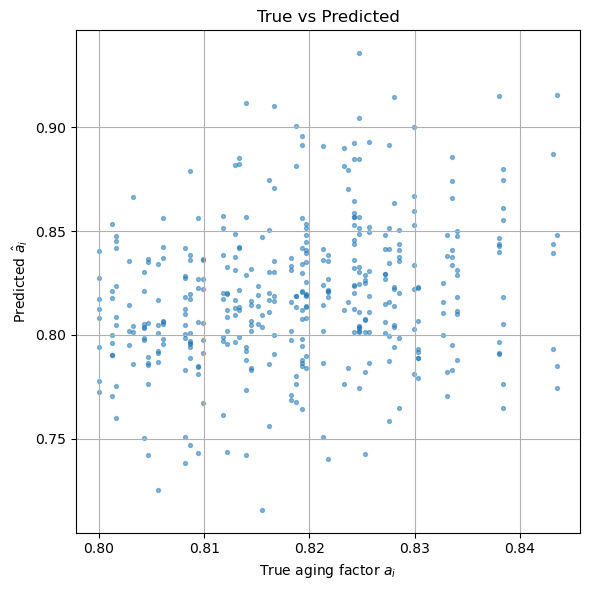

In [29]:
plot_true_vs_predicted(median_df, "a_true", "a_hat_median")

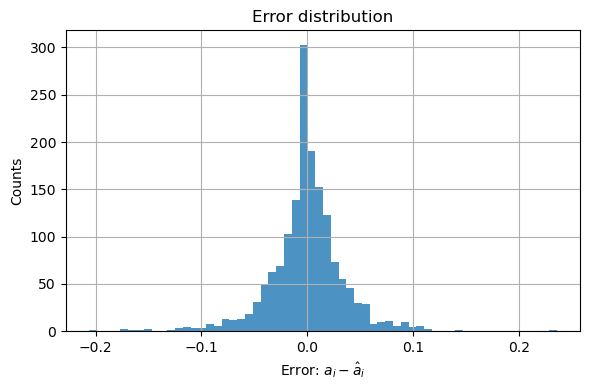

In [ ]:
plot_error_histogram(median_df, "a_true", "a_hat_median")